In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
data=pd.read_csv('spotify_data clean.csv')
data.head()

,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type,track_duration_min
0,3EJS5LyekDim1Tf5rBFmZl,Trippy Mane (ft. Project Pat),4,0,True,Diplo,77,2812821,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.55
1,1oQW6G2ZiwMuHqlPpP27DB,OMG!,1,0,True,Yelawolf,64,2363438,"country hip hop, southern hip hop",4SUmmwnv0xTjRcLdjczGg2,OMG!,2025-10-31,1,single,3.07
2,7mdkjzoIYlf1rx9EtBpGmU,Hard 2 Find,1,4,True,Riff Raff,48,193302,NaN,3E3zEAL8gUYWaLYB9L7gbp,Hard 2 Find,2025-10-31,1,single,2.55
3,67rW0Zl7oB3qEpD5YWWE5w,Still Get Like That (ft. Project Pat & Starrah),8,30,True,Diplo,77,2813710,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.69
4,15xptTfRBrjsppW0INUZjf,ride me like a harley,2,0,True,Rumelis,48,8682,dark r&b,06FDIpSHYmZAZoyuYtc7kd,come closer / ride me like a harley,2025-10-30,2,single,2.39


In [274]:
data.shape

(8582, 15)

In [3]:
data.columns

Index(['track_id', 'track_name', 'track_number', 'track_popularity',
       'explicit', 'artist_name', 'artist_popularity', 'artist_followers',
       'artist_genres', 'album_id', 'album_name', 'album_release_date',
       'album_total_tracks', 'album_type', 'track_duration_min'],
      dtype='object')

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8582 entries, 0 to 8581
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   track_id            8582 non-null   object 
 1   track_name          8582 non-null   object 
 2   track_number        8582 non-null   int64  
 3   track_popularity    8582 non-null   int64  
 4   explicit            8582 non-null   bool   
 5   artist_name         8579 non-null   object 
 6   artist_popularity   8582 non-null   int64  
 7   artist_followers    8582 non-null   int64  
 8   artist_genres       5221 non-null   object 
 9   album_id            8582 non-null   object 
 10  album_name          8582 non-null   object 
 11  album_release_date  8582 non-null   object 
 12  album_total_tracks  8582 non-null   int64  
 13  album_type          8582 non-null   object 
 14  track_duration_min  8582 non-null   float64
dtypes: bool(1), float64(1), int64(5), object(8)
memory usag

In [276]:
data.isna().sum()

track_id                 0
track_name               0
track_number             0
track_popularity         0
explicit                 0
artist_name              3
artist_popularity        0
artist_followers         0
artist_genres         3361
album_id                 0
album_name               0
album_release_date       0
album_total_tracks       0
album_type               0
track_duration_min       0
dtype: int64

In [5]:
data.duplicated().sum()

np.int64(0)

In [6]:
numerical_cols= data.select_dtypes(include=['int64','float64']).columns
categorical_cols=data.select_dtypes(include=['object', 'bool']).columns

print('Numeric Columns:', numerical_cols.tolist())
print('Categorical Columns:', categorical_cols.tolist())

Numeric Columns: ['track_number', 'track_popularity', 'artist_popularity', 'artist_followers', 'album_total_tracks', 'track_duration_min']
Categorical Columns: ['track_id', 'track_name', 'explicit', 'artist_name', 'artist_genres', 'album_id', 'album_name', 'album_release_date', 'album_type']


In [7]:
numerical_cols=['track_number', 'track_popularity', 'artist_followers', 'album_total_tracks', 'track_duration_min']

for col in numerical_cols:
   data[col]= data[col].fillna(data[col].median())

data['artist_genres']= data['artist_genres'].fillna('unknown')


In [8]:
data['artist_genres'].head()

0                           moombahton
1    country hip hop, southern hip hop
2                              unknown
3                           moombahton
4                             dark r&b
Name: artist_genres, dtype: object

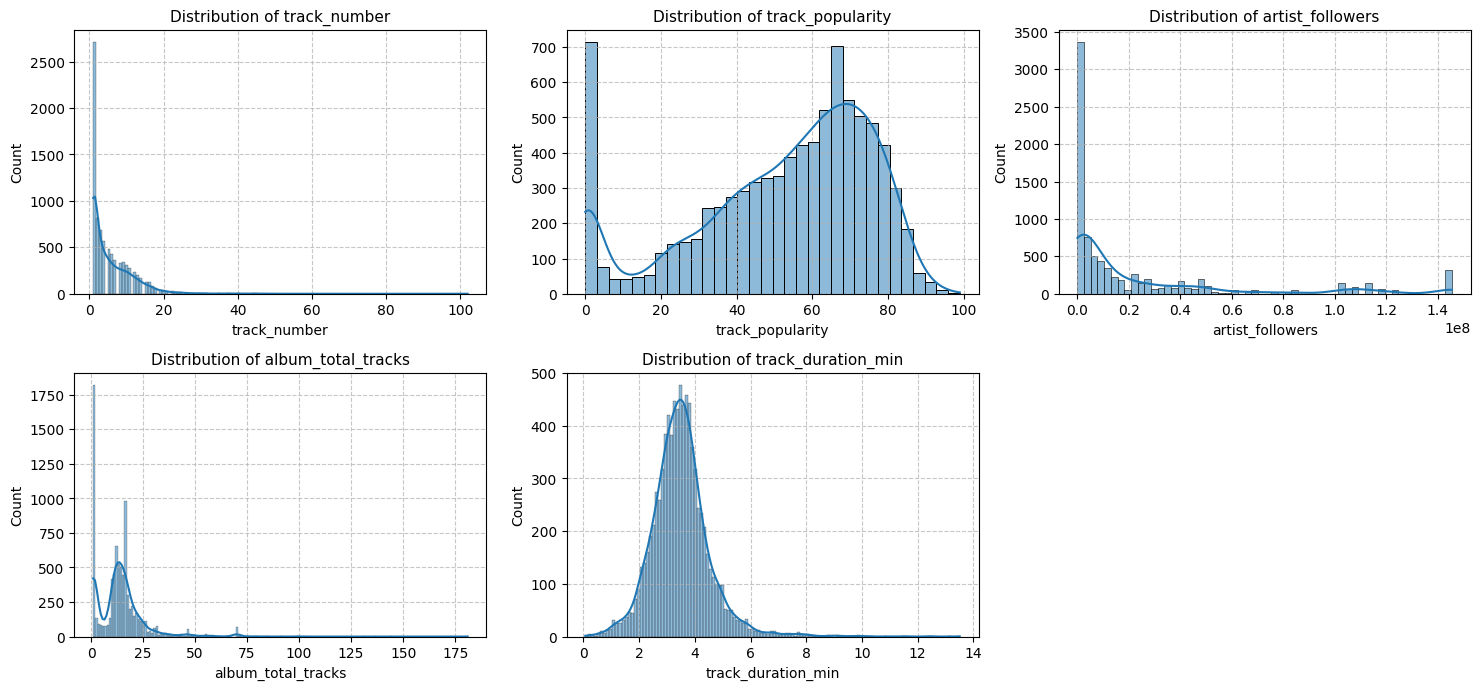

In [9]:
plt.figure(figsize=(15,10))

for i,col in enumerate(numerical_cols,1):
    plt.subplot(3,3,i)
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}', fontsize=11)
    plt.grid(alpha=0.7, linestyle='--', axis='both')
plt.tight_layout()
plt.show()

In [10]:
top_artists= data['artist_name'].value_counts().head(5).index
df_top= data[data['artist_name'].isin(top_artists)]
mean_top=df_top.groupby('artist_name')['artist_followers'].sum()
mean_top.sort_values(ascending=False)

artist_name
Taylor Swift     47122548194
The Weeknd       15926749601
Ariana Grande    10094631410
Lana Del Rey      5127807218
Nirvana           2128515578
Name: artist_followers, dtype: int64

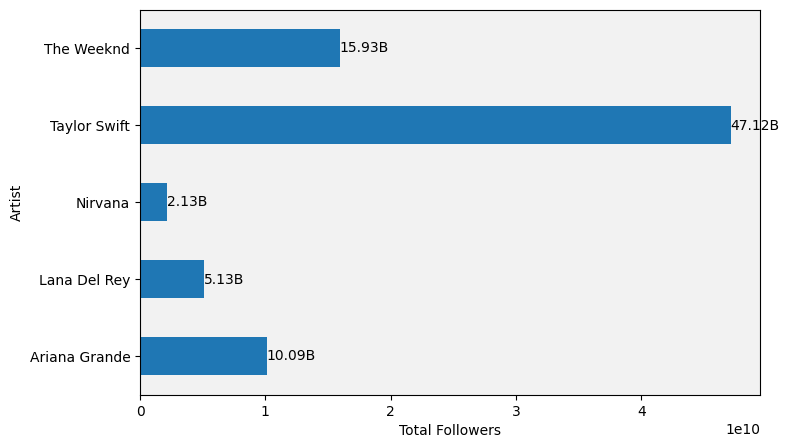

In [11]:
ax= mean_top.plot.barh(figsize=(8,5))
ax.set_facecolor('#f2f2f2')
for i,v in enumerate(mean_top.values):
    ax.text(v,i,f"{v/1e9:.2f}B", va='center', ha='left')
plt.xlabel('Total Followers')
plt.ylabel('Artist')
plt.show()



In [12]:
top_artists= data['artist_name'].value_counts().head(5).index
df_top= data[data['artist_name'].isin(top_artists)]
mean_top=df_top.groupby('artist_name')['track_popularity'].mean()
mean_top.sort_values(ascending=False)

artist_name
Ariana Grande    63.914894
Lana Del Rey     63.171717
The Weeknd       60.787234
Taylor Swift     60.049383
Nirvana          32.450549
Name: track_popularity, dtype: float64

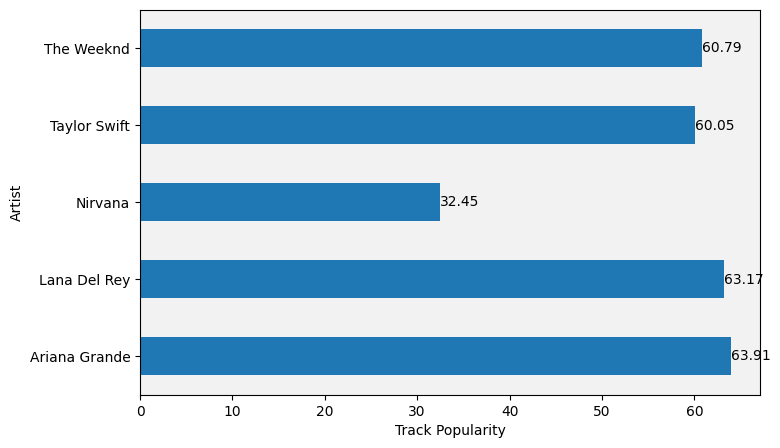

In [13]:
ax= mean_top.plot.barh(figsize=(8,5))
ax.set_facecolor('#f2f2f2')
for i,v in enumerate(mean_top.values):
    ax.text(v,i,f"{v:0.2f}", va='center', ha='left')
plt.xlabel('Track Popularity')
plt.ylabel('Artist')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

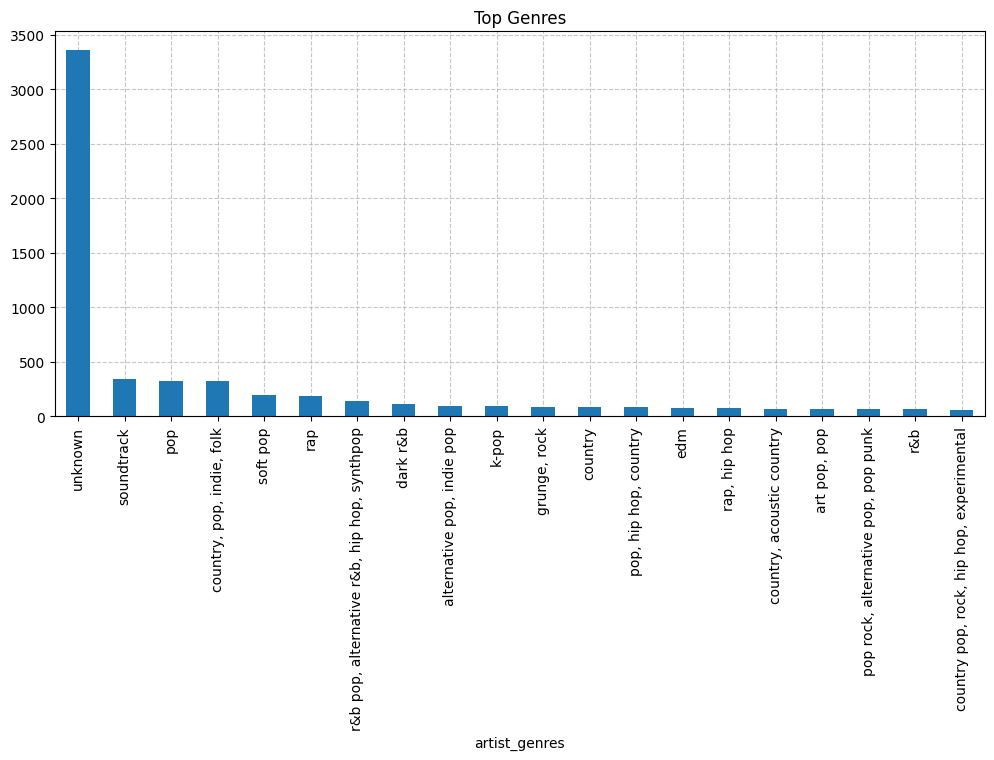

In [303]:
ax=data['artist_genres'].value_counts().head(20).plot(kind='bar',figsize=(12,5))
plt.title('Top Genres')
plt.grid(axis='both', alpha=0.7, linestyle='--')
ax.set_axisbelow(True)
plt.show

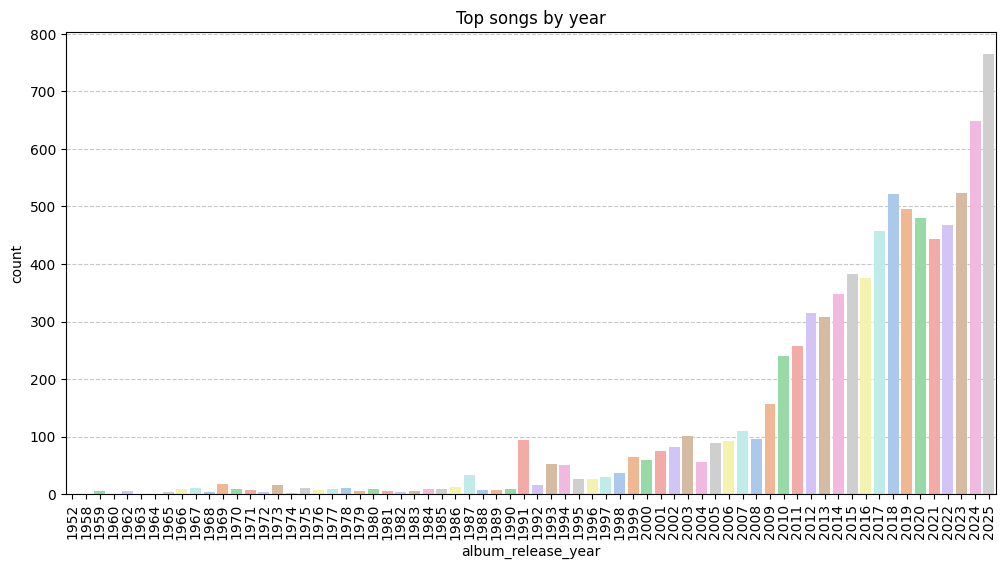

In [16]:
data['album_release_year']= pd.to_datetime(data['album_release_date']).dt.year
plt.figure(figsize=(12,6))
ax=sns.countplot(data=data, x='album_release_year', palette='pastel', hue='album_release_year', legend=False)
plt.xticks(rotation=90)
plt.title('Top songs by year')
ax.set_axisbelow(True)
ax.grid(linestyle='--', alpha=0.7, axis='y')
plt.show()                              

In [332]:
top_singer= data.groupby('artist_name')['artist_followers'].max().sort_values(ascending=False).head(10)
top_singer

artist_name
Taylor Swift     145542136
Ed Sheeran       122802777
Billie Eilish    118797451
The Weeknd       113039308
Ariana Grande    107418606
Eminem           104584370
Drake            103126025
Bad Bunny        102610644
Justin Bieber     85050158
BTS               81197976
Name: artist_followers, dtype: int64

In [17]:
top_popularity= data.groupby('artist_name')['artist_popularity'].max().sort_values(ascending=False).head(10)
top_popularity

artist_name
Taylor Swift         100
Drake                 95
Bad Bunny             95
The Weeknd            94
Justin Bieber         91
Sabrina Carpenter     91
Rihanna               90
Billie Eilish         90
Ariana Grande         90
Bruno Mars            90
Name: artist_popularity, dtype: int64